# Hospital Readmission Risk Prediction & Analytics

## Data Understanding and Exploratory Data Analysis

This notebook focuses on understanding, cleaning, and exploring the hospital readmission dataset.

### Project Objective
The objective of this project is to predict whether a diabetic patient will be readmitted to the hospital within 30 days of discharge.

### Dataset
Diabetes 130-US Hospitals for Years 1999-2008

### Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- SQLite

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# Load the dataset

df = pd.read_csv("../data/diabetic_data.csv")

print("Dataset loaded successfully.")
print("Shape of dataset:", df.shape)

Dataset loaded successfully.
Shape of dataset: (101766, 50)


In [ ]:
# Display the first 5 rows

df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [ ]:
# Check dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

In [ ]:
# Check missing values

missing_values = df.isnull().sum()

missing_values[missing_values > 0].sort_values(ascending=False)

max_glu_serum    96420
A1Cresult        84748
dtype: int64

In [ ]:
# Check '?' values in the dataset

question_mark_counts = (df == "?").sum()

question_mark_counts[question_mark_counts > 0].sort_values(ascending=False)

weight               98569
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
dtype: int64

In [ ]:
# Create a copy of the original dataset for cleaning

df_clean = df.copy()

print("Clean copy created successfully.")
print("Shape:", df_clean.shape)

Clean copy created successfully.
Shape: (101766, 50)


In [ ]:
# Remove columns with a very high percentage of unknown values

df_clean.drop(
    columns=["weight", "medical_specialty", "payer_code"],
    inplace=True
)

# Replace '?' with 'Unknown'
df_clean.replace("?", "Unknown", inplace=True)

# Replace missing lab results with 'Not measured'
df_clean["A1Cresult"] = df_clean["A1Cresult"].fillna("Not measured")
df_clean["max_glu_serum"] = df_clean["max_glu_serum"].fillna("Not measured")

print("Missing values handled successfully.")
print("New shape:", df_clean.shape)

Missing values handled successfully.
New shape: (101766, 47)


In [ ]:
# Verify remaining missing values

print("Remaining NaN values:")
print(df_clean.isnull().sum().sum())

print("\nRemaining '?' values:")
print((df_clean == "?").sum().sum())

Remaining NaN values:
0

Remaining '?' values:
0


In [ ]:
# Check for duplicate rows

duplicate_count = df_clean.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [ ]:
# Check unique encounters and patients

unique_encounters = df_clean["encounter_id"].nunique()
unique_patients = df_clean["patient_nbr"].nunique()

print("Unique encounters:", unique_encounters)
print("Unique patients:", unique_patients)

Unique encounters: 101766
Unique patients: 71518


In [ ]:
# Create binary target variable for 30-day readmission

df_clean["readmitted_30"] = df_clean["readmitted"].map({
    "<30": 1,
    ">30": 0,
    "NO": 0
})

print("Target variable created successfully.")
print("\nTarget distribution:")
print(df_clean["readmitted_30"].value_counts())

Target variable created successfully.

Target distribution:
readmitted_30
0    90409
1    11357
Name: count, dtype: int64


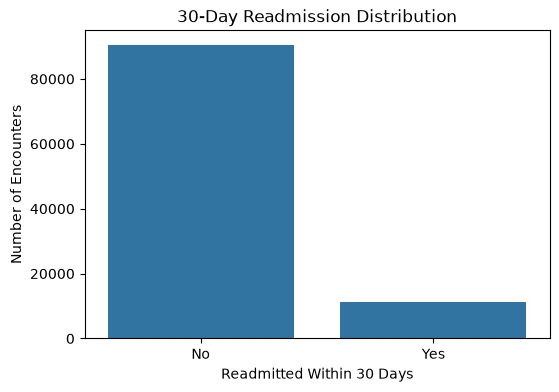

In [ ]:
# Visualize 30-day readmission distribution

plt.figure(figsize=(6, 4))

sns.countplot(
    data=df_clean,
    x="readmitted_30"
)

plt.title("30-Day Readmission Distribution")
plt.xlabel("Readmitted Within 30 Days")
plt.ylabel("Number of Encounters")
plt.xticks([0, 1], ["No", "Yes"])

plt.show()

In [ ]:
# Calculate percentage of each target class

target_percentage = (
    df_clean["readmitted_30"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("30-Day Readmission Percentage:")
print(target_percentage)

30-Day Readmission Percentage:
readmitted_30
0    88.84
1    11.16
Name: proportion, dtype: float64


In [ ]:
# Calculate 30-day readmission rate by previous inpatient visits

inpatient_readmission_rate = (
    df_clean.groupby("number_inpatient")["readmitted_30"]
    .mean()
    .mul(100)
    .round(2)
)

print("30-Day Readmission Rate by Previous Inpatient Visits:")
print(inpatient_readmission_rate)

30-Day Readmission Rate by Previous Inpatient Visits:
number_inpatient
0       8.44
1      12.92
2      17.43
3      20.29
4      23.61
5      31.40
6      34.58
7      35.45
8      44.37
9      42.34
10     42.62
11     67.35
12     50.00
13     50.00
14     40.00
15    100.00
16     33.33
17    100.00
18      0.00
19     50.00
21    100.00
Name: readmitted_30, dtype: float64


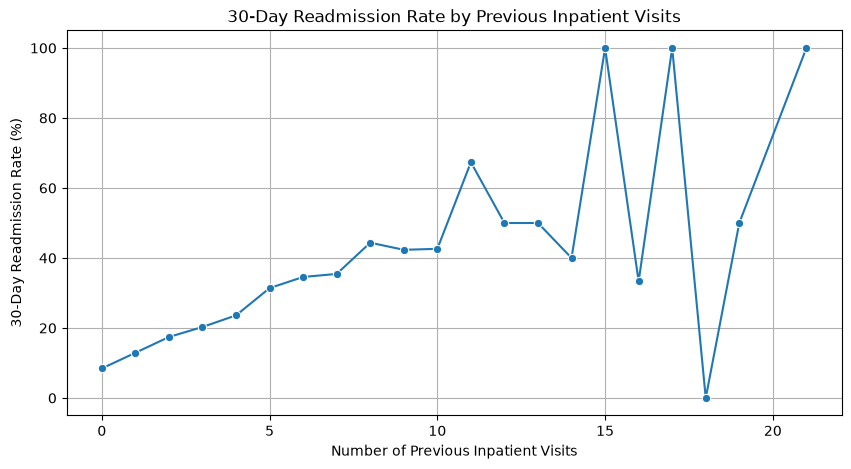

In [ ]:
# Visualize readmission rate by previous inpatient visits

plt.figure(figsize=(10, 5))

sns.lineplot(
    x=inpatient_readmission_rate.index,
    y=inpatient_readmission_rate.values,
    marker="o"
)

plt.title("30-Day Readmission Rate by Previous Inpatient Visits")
plt.xlabel("Number of Previous Inpatient Visits")
plt.ylabel("30-Day Readmission Rate (%)")
plt.grid(True)

plt.show()

In [ ]:
# Calculate 30-day readmission rate by age group

age_readmission_rate = (
    df_clean.groupby("age")["readmitted_30"]
    .mean()
    .mul(100)
    .round(2)
)

print("30-Day Readmission Rate by Age Group:")
print(age_readmission_rate)

30-Day Readmission Rate by Age Group:
age
[0-10)       1.86
[10-20)      5.79
[20-30)     14.24
[30-40)     11.23
[40-50)     10.60
[50-60)      9.67
[60-70)     11.13
[70-80)     11.77
[80-90)     12.08
[90-100)    11.10
Name: readmitted_30, dtype: float64


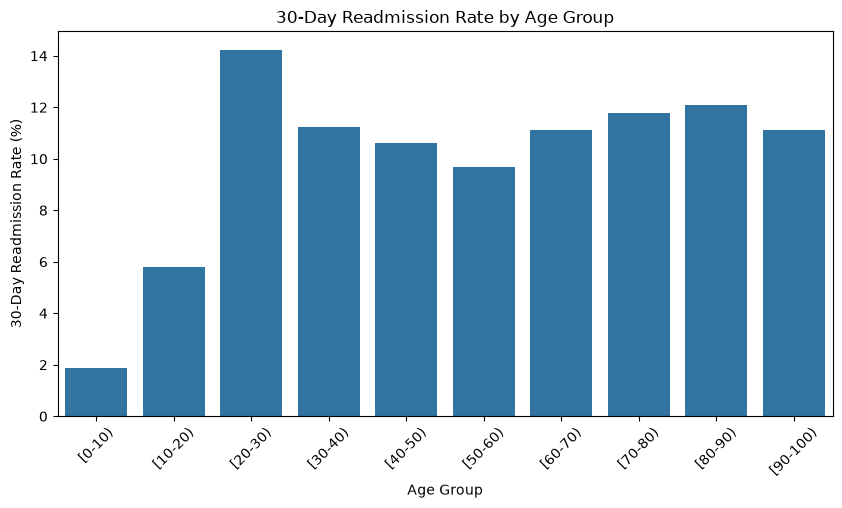

In [ ]:
# Visualize 30-day readmission rate by age group

plt.figure(figsize=(10, 5))

sns.barplot(
    x=age_readmission_rate.index,
    y=age_readmission_rate.values
)

plt.title("30-Day Readmission Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("30-Day Readmission Rate (%)")
plt.xticks(rotation=45)

plt.show()

In [ ]:
# Calculate 30-day readmission rate by gender

gender_readmission_rate = (
    df_clean.groupby("gender")["readmitted_30"]
    .mean()
    .mul(100)
    .round(2)
)

print("30-Day Readmission Rate by Gender:")
print(gender_readmission_rate)

30-Day Readmission Rate by Gender:
gender
Female             11.25
Male               11.06
Unknown/Invalid     0.00
Name: readmitted_30, dtype: float64


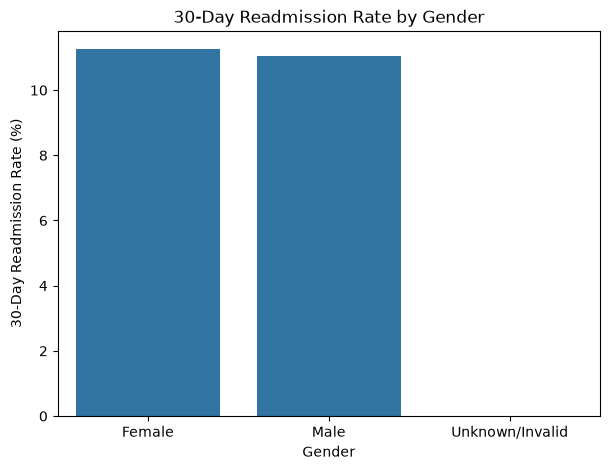

In [ ]:
# Visualize 30-day readmission rate by gender

plt.figure(figsize=(7, 5))

sns.barplot(
    x=gender_readmission_rate.index,
    y=gender_readmission_rate.values
)

plt.title("30-Day Readmission Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("30-Day Readmission Rate (%)")

plt.show()

In [ ]:
# Compare healthcare utilization between readmission groups

utilization_columns = [
    "number_outpatient",
    "number_emergency",
    "number_inpatient"
]

utilization_summary = (
    df_clean.groupby("readmitted_30")[utilization_columns]
    .mean()
    .round(2)
)

utilization_summary.index = ["No Readmission", "Readmitted <30 Days"]

print("Average Healthcare Utilization:")
utilization_summary

Average Healthcare Utilization:


,number_outpatient,number_emergency,number_inpatient
No Readmission,0.36,0.18,0.56
Readmitted <30 Days,0.44,0.36,1.22


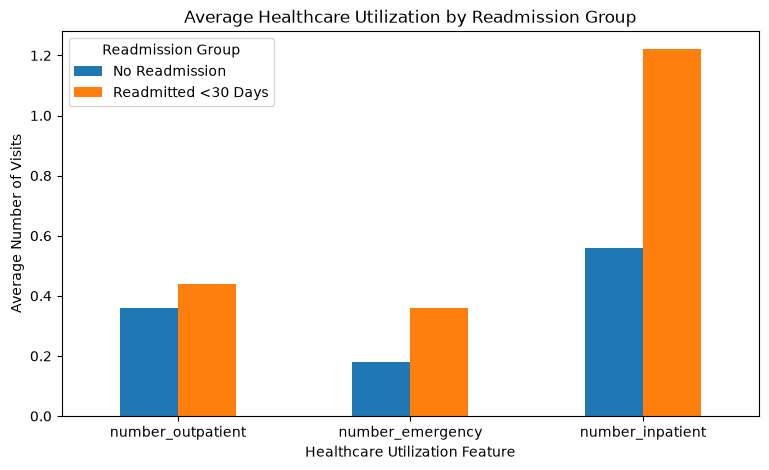

In [ ]:
# Visualize average healthcare utilization by readmission group

utilization_plot = utilization_summary.T

utilization_plot.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Average Healthcare Utilization by Readmission Group")
plt.xlabel("Healthcare Utilization Feature")
plt.ylabel("Average Number of Visits")
plt.xticks(rotation=0)
plt.legend(title="Readmission Group")

plt.show()

In [ ]:
# Compare average hospital stay by readmission group

hospital_stay_summary = (
    df_clean.groupby("readmitted_30")["time_in_hospital"]
    .mean()
    .round(2)
)

hospital_stay_summary.index = ["No Readmission", "Readmitted <30 Days"]

print("Average Length of Hospital Stay:")
hospital_stay_summary

Average Length of Hospital Stay:


No Readmission         4.35
Readmitted <30 Days    4.77
Name: time_in_hospital, dtype: float64

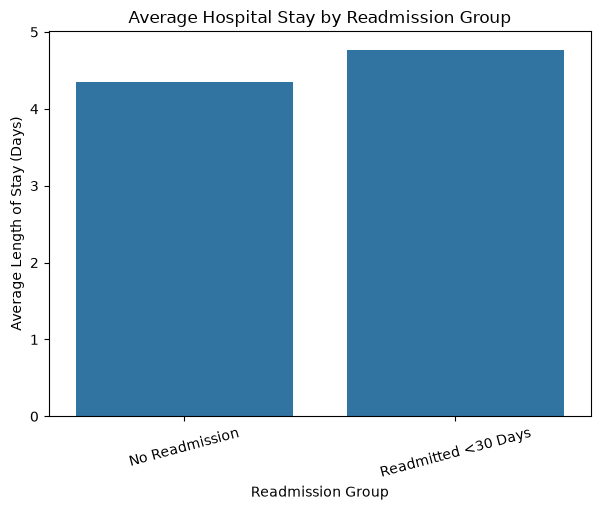

In [ ]:
# Visualize average hospital stay by readmission group

plt.figure(figsize=(7, 5))

sns.barplot(
    x=hospital_stay_summary.index,
    y=hospital_stay_summary.values
)

plt.title("Average Hospital Stay by Readmission Group")
plt.xlabel("Readmission Group")
plt.ylabel("Average Length of Stay (Days)")
plt.xticks(rotation=15)

plt.show()

In [ ]:
# Calculate 30-day readmission rate by diabetes medication status

diabetes_med_readmission_rate = (
    df_clean.groupby("diabetesMed")["readmitted_30"]
    .mean()
    .mul(100)
    .round(2)
)

print("30-Day Readmission Rate by Diabetes Medication Status:")
print(diabetes_med_readmission_rate)

30-Day Readmission Rate by Diabetes Medication Status:
diabetesMed
No      9.60
Yes    11.63
Name: readmitted_30, dtype: float64


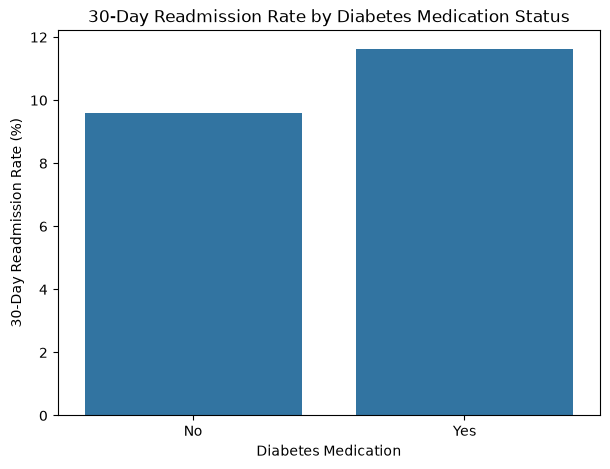

In [ ]:
# Visualize 30-day readmission rate by diabetes medication status

plt.figure(figsize=(7, 5))

sns.barplot(
    x=diabetes_med_readmission_rate.index,
    y=diabetes_med_readmission_rate.values
)

plt.title("30-Day Readmission Rate by Diabetes Medication Status")
plt.xlabel("Diabetes Medication")
plt.ylabel("30-Day Readmission Rate (%)")

plt.show()

In [ ]:
# Function to group diagnosis codes

def map_diagnosis(code):
    if code == "Unknown":
        return "Unknown"

    if str(code).startswith("V"):
        return "Supplementary"

    try:
        code = float(code)
    except:
        return "Other"

    if 1 <= code < 140:
        return "Infectious"
    elif 140 <= code < 240:
        return "Neoplasms"
    elif 240 <= code < 250:
        return "Endocrine"
    elif 250 <= code < 251:
        return "Diabetes"
    elif 251 <= code < 280:
        return "Metabolic"
    elif 280 <= code < 290:
        return "Blood"
    elif 290 <= code < 320:
        return "Mental"
    elif 320 <= code < 390:
        return "Nervous/Sensory"
    elif 390 <= code < 460:
        return "Circulatory"
    elif 460 <= code < 520:
        return "Respiratory"
    elif 520 <= code < 580:
        return "Digestive"
    elif 580 <= code < 630:
        return "Genitourinary"
    elif 630 <= code < 680:
        return "Pregnancy"
    elif 680 <= code < 710:
        return "Skin"
    elif 710 <= code < 740:
        return "Musculoskeletal"
    elif 740 <= code < 760:
        return "Congenital"
    elif 760 <= code < 780:
        return "Perinatal"
    elif 780 <= code < 800:
        return "Symptoms"
    elif 800 <= code <= 999:
        return "Injury/Poisoning"
    else:
        return "Other"


# Create grouped diagnosis columns

df_clean["diag_1_group"] = df_clean["diag_1"].apply(map_diagnosis)
df_clean["diag_2_group"] = df_clean["diag_2"].apply(map_diagnosis)
df_clean["diag_3_group"] = df_clean["diag_3"].apply(map_diagnosis)

print("Diagnosis groups created successfully.")

print("\nPrimary diagnosis groups:")
print(df_clean["diag_1_group"].value_counts().head(10))

Diagnosis groups created successfully.

Primary diagnosis groups:
diag_1_group
Circulatory         30336
Respiratory         10407
Digestive            9208
Diabetes             8757
Symptoms             7636
Injury/Poisoning     6974
Genitourinary        5078
Musculoskeletal      4957
Neoplasms            3433
Infectious           2768
Name: count, dtype: int64


In [ ]:
# Calculate 30-day readmission rate by primary diagnosis group

diagnosis_readmission_rate = (
    df_clean.groupby("diag_1_group")["readmitted_30"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

print("30-Day Readmission Rate by Primary Diagnosis Group:")
print(diagnosis_readmission_rate)

30-Day Readmission Rate by Primary Diagnosis Group:
diag_1_group
Unknown             23.81
Supplementary       16.18
Blood               13.42
Diabetes            12.98
Metabolic           12.26
Injury/Poisoning    12.25
Mental              12.20
Circulatory         11.45
Infectious          11.45
Genitourinary       10.81
Respiratory         10.69
Digestive           10.49
Nervous/Sensory     10.32
Neoplasms           10.08
Skin                 9.88
Musculoskeletal      9.50
Endocrine            9.00
Symptoms             9.00
Congenital           7.84
Pregnancy            6.11
Other                0.00
Name: readmitted_30, dtype: float64


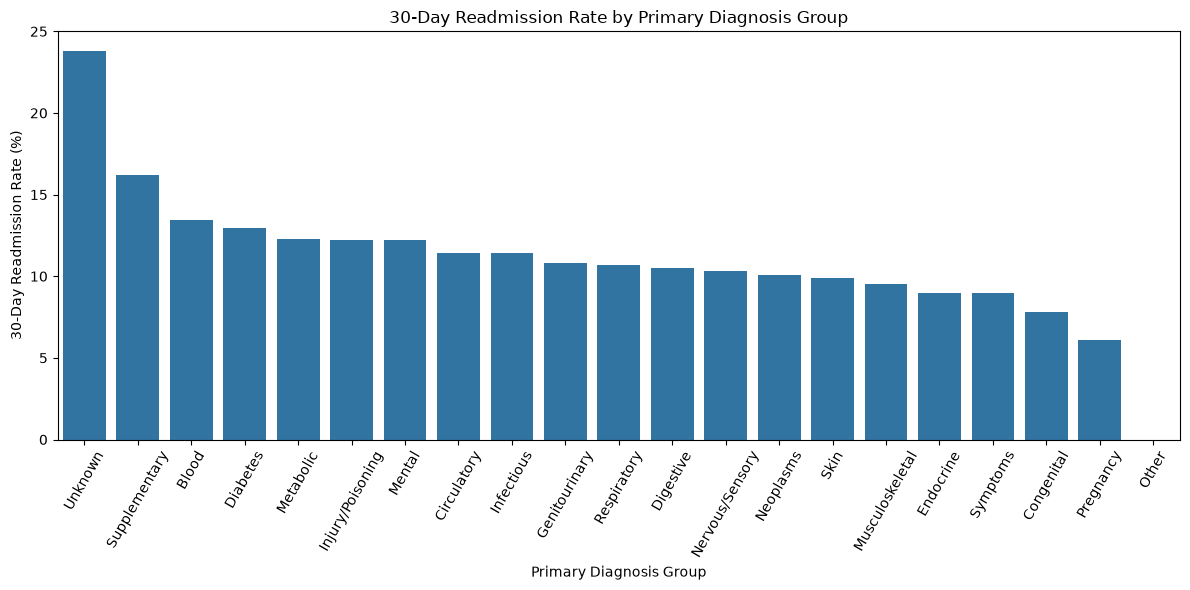

In [ ]:
# Visualize 30-day readmission rate by primary diagnosis group

plt.figure(figsize=(12, 6))

sns.barplot(
    x=diagnosis_readmission_rate.index,
    y=diagnosis_readmission_rate.values
)

plt.title("30-Day Readmission Rate by Primary Diagnosis Group")
plt.xlabel("Primary Diagnosis Group")
plt.ylabel("30-Day Readmission Rate (%)")
plt.xticks(rotation=60)

plt.tight_layout()
plt.show()

In [ ]:
# Compare clinical activity between readmission groups

clinical_activity_columns = [
    "num_lab_procedures",
    "num_procedures",
    "num_medications"
]

clinical_activity_summary = (
    df_clean.groupby("readmitted_30")[clinical_activity_columns]
    .mean()
    .round(2)
)

clinical_activity_summary.index = [
    "No Readmission",
    "Readmitted <30 Days"
]

print("Average Clinical Activity:")
clinical_activity_summary

Average Clinical Activity:


,num_lab_procedures,num_procedures,num_medications
No Readmission,42.95,1.35,15.91
Readmitted <30 Days,44.23,1.28,16.90


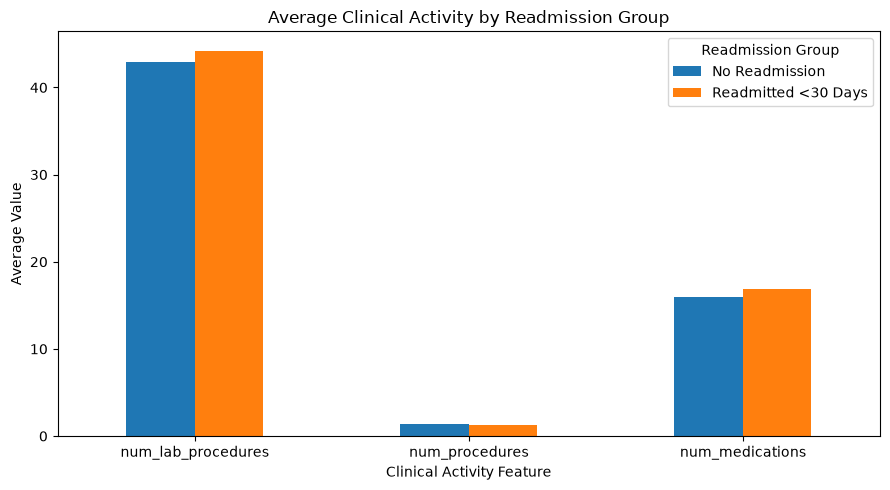

In [ ]:
# Visualize average clinical activity by readmission group

clinical_activity_plot = clinical_activity_summary.T

clinical_activity_plot.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Average Clinical Activity by Readmission Group")
plt.xlabel("Clinical Activity Feature")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.legend(title="Readmission Group")

plt.tight_layout()
plt.show()

In [ ]:
# Remove identifier columns from the modeling dataset

model_df = df_clean.drop(
    columns=["encounter_id", "patient_nbr"]
).copy()

print("Identifier columns removed successfully.")
print("New shape:", model_df.shape)

Identifier columns removed successfully.
New shape: (101766, 49)


In [ ]:
# Remove original diagnosis code columns

model_df.drop(
    columns=["diag_1", "diag_2", "diag_3"],
    inplace=True
)

print("Original diagnosis columns removed.")
print("Current shape:", model_df.shape)

Original diagnosis columns removed.
Current shape: (101766, 46)


In [ ]:
# Convert hospital administrative IDs to categorical features

categorical_id_columns = [
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id"
]

for col in categorical_id_columns:
    model_df[col] = model_df[col].astype(str)

print("Hospital ID columns converted to categorical type.")

print("\nData types:")
print(model_df[categorical_id_columns].dtypes)

Hospital ID columns converted to categorical type.

Data types:
admission_type_id           str
discharge_disposition_id    str
admission_source_id         str
dtype: object


In [ ]:
# Group very rare hospital administrative categories

for col in categorical_id_columns:
    category_counts = model_df[col].value_counts()
    
    rare_categories = category_counts[category_counts < 100].index
    
    model_df[col] = model_df[col].replace(
        rare_categories,
        "Other"
    )

print("Rare categories grouped successfully.")

for col in categorical_id_columns:
    print(f"\n{col}:")
    print(model_df[col].value_counts())

Rare categories grouped successfully.

admission_type_id:
admission_type_id
1        53990
3        18869
2        18480
6         5291
5         4785
8          320
Other       31
Name: count, dtype: int64

discharge_disposition_id:
discharge_disposition_id
1        60234
3        13954
6        12902
18        3691
2         2128
22        1993
11        1642
5         1184
25         989
4          815
7          623
23         412
13         399
14         372
Other      181
28         139
8          108
Name: count, dtype: int64

admission_source_id:
admission_source_id
7        57494
1        29565
17        6781
4         3187
6         2264
2         1104
5          855
3          187
20         161
9          125
Other       43
Name: count, dtype: int64


In [ ]:
# Convert diagnosis groups to categorical features

diagnosis_columns = [
    "diag_1_group",
    "diag_2_group",
    "diag_3_group"
]

for col in diagnosis_columns:
    model_df[col] = model_df[col].astype(str)

print("Diagnosis group columns converted to categorical type.")

print("\nData types:")
print(model_df[diagnosis_columns].dtypes)

Diagnosis group columns converted to categorical type.

Data types:
diag_1_group    str
diag_2_group    str
diag_3_group    str
dtype: object


In [ ]:
# Separate numerical and categorical features

numerical_features = model_df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = model_df.select_dtypes(
    include=["object", "string"]
).columns.tolist()

print("Number of numerical features:", len(numerical_features))
print("Number of categorical features:", len(categorical_features))

print("\nNumerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Number of numerical features: 9
Number of categorical features: 37

Numerical features:
['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'readmitted_30']

Categorical features:
['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted', 'diag_1_group', 'diag_2_group', 'diag_3_group']


In [ ]:
# Separate input features (X) and target variable (y)

X = model_df.drop(
    columns=["readmitted", "readmitted_30"]
)

y = model_df["readmitted_30"]

print("Features and target separated successfully.")

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features and target separated successfully.

X shape: (101766, 44)
y shape: (101766,)


In [ ]:
# Import GroupShuffleSplit
from sklearn.model_selection import GroupShuffleSplit

# Use patient number as the grouping variable
groups = df_clean["patient_nbr"]

# Create an 80-20 patient-aware split
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(X, y, groups=groups)
)

# Create training and testing datasets
X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("Patient-aware train-test split completed.")

print("\nTraining set:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting set:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Patient-aware train-test split completed.

Training set:
X_train: (81613, 44)
y_train: (81613,)

Testing set:
X_test: (20153, 44)
y_test: (20153,)


In [ ]:
# Verify that no patient appears in both training and testing sets

train_patients = set(groups.iloc[train_idx])
test_patients = set(groups.iloc[test_idx])

common_patients = train_patients.intersection(test_patients)

print("Number of unique patients in training set:", len(train_patients))
print("Number of unique patients in testing set:", len(test_patients))
print("Patients appearing in both sets:", len(common_patients))

if len(common_patients) == 0:
    print("\n✓ No patient appears in both training and testing sets.")
else:
    print("\n⚠️ Patient overlap detected.")

Number of unique patients in training set: 57214
Number of unique patients in testing set: 14304
Patients appearing in both sets: 0

✓ No patient appears in both training and testing sets.


In [ ]:
# Identify numerical and categorical features for preprocessing

numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "string"]
).columns.tolist()

print("Number of numerical features:", len(numerical_features))
print("Number of categorical features:", len(categorical_features))

print("\nNumerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Number of numerical features: 8
Number of categorical features: 36

Numerical features:
['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

Categorical features:
['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'diag_1_group', 'diag_2_group', 'diag_3_group']


In [ ]:
# Import preprocessing tools
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [ ]:
# Fit the preprocessor on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data using the already-fitted preprocessor
X_test_processed = preprocessor.transform(X_test)

print("Preprocessing completed successfully.")

print("\nOriginal training shape:", X_train.shape)
print("Processed training shape:", X_train_processed.shape)

print("\nOriginal testing shape:", X_test.shape)
print("Processed testing shape:", X_test_processed.shape)

Preprocessing completed successfully.

Original training shape: (81613, 44)
Processed training shape: (81613, 204)

Original testing shape: (20153, 44)
Processed testing shape: (20153, 204)


In [ ]:
# Import Logistic Regression
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

# Train the model
logistic_model.fit(X_train_processed, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [ ]:
# Import evaluation metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# Make predictions
y_pred_logistic = logistic_model.predict(X_test_processed)

# Predict probabilities for ROC-AUC
y_prob_logistic = logistic_model.predict_proba(
    X_test_processed
)[:, 1]

# Classification report
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_logistic))

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_logistic))

# ROC-AUC score
logistic_roc_auc = roc_auc_score(
    y_test,
    y_prob_logistic
)

print("\nROC-AUC Score:", round(logistic_roc_auc, 4))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.69      0.79     18002
           1       0.17      0.55      0.26      2151

    accuracy                           0.67     20153
   macro avg       0.55      0.62      0.52     20153
weighted avg       0.85      0.67      0.73     20153

Confusion Matrix:
[[12343  5659]
 [  978  1173]]

ROC-AUC Score: 0.6656


In [ ]:
# Store Logistic Regression evaluation results

logistic_report = classification_report(
    y_test,
    y_pred_logistic,
    output_dict=True
)

logistic_results = {
    "Model": "Logistic Regression",
    "Precision": logistic_report["1"]["precision"],
    "Recall": logistic_report["1"]["recall"],
    "F1-Score": logistic_report["1"]["f1-score"],
    "ROC-AUC": logistic_roc_auc
}

print("Logistic Regression results stored:")
print(logistic_results)

Logistic Regression results stored:
{'Model': 'Logistic Regression', 'Precision': 0.171692037470726, 'Recall': 0.5453277545327755, 'F1-Score': 0.26115996883001225, 'ROC-AUC': 0.665626994490152}


In [ ]:
# Import Decision Tree
from sklearn.tree import DecisionTreeClassifier

# Create Decision Tree model
decision_tree_model = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42,
    max_depth=10
)

# Train the model
decision_tree_model.fit(
    X_train_processed,
    y_train
)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [ ]:
# Make predictions
y_pred_tree = decision_tree_model.predict(X_test_processed)

# Predict probabilities for ROC-AUC
y_prob_tree = decision_tree_model.predict_proba(
    X_test_processed
)[:, 1]

# Classification report
print("Decision Tree Classification Report:")
print(classification_report(y_test, y_pred_tree))

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tree))

# ROC-AUC score
tree_roc_auc = roc_auc_score(
    y_test,
    y_prob_tree
)

print("\nROC-AUC Score:", round(tree_roc_auc, 4))

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.70      0.80     18002
           1       0.17      0.52      0.26      2151

    accuracy                           0.68     20153
   macro avg       0.55      0.61      0.53     20153
weighted avg       0.84      0.68      0.74     20153

Confusion Matrix:
[[12639  5363]
 [ 1040  1111]]

ROC-AUC Score: 0.639


In [ ]:
# Store Decision Tree evaluation results

tree_report = classification_report(
    y_test,
    y_pred_tree,
    output_dict=True
)

tree_results = {
    "Model": "Decision Tree",
    "Precision": tree_report["1"]["precision"],
    "Recall": tree_report["1"]["recall"],
    "F1-Score": tree_report["1"]["f1-score"],
    "ROC-AUC": tree_roc_auc
}

print("Decision Tree results stored:")
print(tree_results)

Decision Tree results stored:
{'Model': 'Decision Tree', 'Precision': 0.17160951498300897, 'Recall': 0.5165039516503952, 'F1-Score': 0.2576231884057971, 'ROC-AUC': 0.6389779331817618}


In [ ]:
# Import Random Forest
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Train the model
random_forest_model.fit(
    X_train_processed,
    y_train
)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [ ]:
# Import Random Forest
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Train the model
random_forest_model.fit(
    X_train_processed,
    y_train
)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [ ]:
# Make predictions
y_pred_rf = random_forest_model.predict(X_test_processed)

# Predict probabilities for ROC-AUC
y_prob_rf = random_forest_model.predict_proba(
    X_test_processed
)[:, 1]

# Classification report
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

# ROC-AUC score
rf_roc_auc = roc_auc_score(
    y_test,
    y_prob_rf
)

print("\nROC-AUC Score:", round(rf_roc_auc, 4))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.66      0.77     18002
           1       0.17      0.58      0.26      2151

    accuracy                           0.65     20153
   macro avg       0.55      0.62      0.52     20153
weighted avg       0.85      0.65      0.72     20153

Confusion Matrix:
[[11845  6157]
 [  896  1255]]

ROC-AUC Score: 0.6691


In [ ]:
# Store Random Forest evaluation results

rf_report = classification_report(
    y_test,
    y_pred_rf,
    output_dict=True
)

rf_results = {
    "Model": "Random Forest",
    "Precision": rf_report["1"]["precision"],
    "Recall": rf_report["1"]["recall"],
    "F1-Score": rf_report["1"]["f1-score"],
    "ROC-AUC": rf_roc_auc
}

print("Random Forest results stored:")
print(rf_results)

Random Forest results stored:
{'Model': 'Random Forest', 'Precision': 0.1693200215866163, 'Recall': 0.5834495583449558, 'F1-Score': 0.2624699362124856, 'ROC-AUC': 0.66909347228375}


In [ ]:
# Compare all three baseline models

model_comparison = pd.DataFrame([
    logistic_results,
    tree_results,
    rf_results
])

print("Model Comparison:")
model_comparison

Model Comparison:


,Model,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.171692,0.545328,0.261160,0.665627
1,Decision Tree,0.171610,0.516504,0.257623,0.638978
2,Random Forest,0.169320,0.583450,0.262470,0.669093


In [ ]:
# Import tools for hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

# Define Random Forest hyperparameter search space
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [8, 10, 12, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

print("Random Forest hyperparameter search space created.")

Random Forest hyperparameter search space created.


In [ ]:
# Create RandomizedSearchCV for Random Forest

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=param_grid,
    n_iter=10,
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Run hyperparameter search
rf_search.fit(
    X_train_processed,
    y_train
)

print("Random Forest hyperparameter tuning completed.")

Fitting 3 folds for each of 10 candidates, totalling 30 fits


In [ ]:
# Display the best hyperparameters and cross-validation score

print("Best Random Forest Parameters:")
print(rf_search.best_params_)

print("\nBest Cross-Validation ROC-AUC:")
print(round(rf_search.best_score_, 4))

Best Random Forest Parameters:
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 15}

Best Cross-Validation ROC-AUC:
0.6713


In [ ]:
# Get the best Random Forest model from the hyperparameter search
best_rf = rf_search.best_estimator_

# Make predictions on the test set
y_pred_best_rf = best_rf.predict(X_test_processed)

# Predict probabilities for ROC-AUC
y_prob_best_rf = best_rf.predict_proba(
    X_test_processed
)[:, 1]

# Classification report
print("Tuned Random Forest Classification Report:")
print(classification_report(y_test, y_pred_best_rf))

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_best_rf))

# ROC-AUC score
tuned_rf_roc_auc = roc_auc_score(
    y_test,
    y_prob_best_rf
)

print("\nTuned Random Forest ROC-AUC:",
      round(tuned_rf_roc_auc, 4))

Tuned Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.71      0.80     18002
           1       0.18      0.54      0.27      2151

    accuracy                           0.69     20153
   macro avg       0.55      0.62      0.54     20153
weighted avg       0.85      0.69      0.74     20153

Confusion Matrix:
[[12714  5288]
 [  997  1154]]

Tuned Random Forest ROC-AUC: 0.6739


In [ ]:
# Store tuned Random Forest evaluation results

tuned_rf_report = classification_report(
    y_test,
    y_pred_best_rf,
    output_dict=True
)

tuned_rf_results = {
    "Model": "Tuned Random Forest",
    "Precision": tuned_rf_report["1"]["precision"],
    "Recall": tuned_rf_report["1"]["recall"],
    "F1-Score": tuned_rf_report["1"]["f1-score"],
    "ROC-AUC": tuned_rf_roc_auc
}

print("Tuned Random Forest results stored:")
print(tuned_rf_results)

Tuned Random Forest results stored:
{'Model': 'Tuned Random Forest', 'Precision': 0.17913691400186277, 'Recall': 0.5364946536494654, 'F1-Score': 0.26859071337134877, 'ROC-AUC': 0.6738883060206493}


In [ ]:
# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Get feature importance from tuned Random Forest
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_rf.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

print("Top 20 Important Features:")
feature_importance.head(20)

Top 20 Important Features:


,Feature,Importance
6,num__number_inpatient,0.178434
3,num__num_medications,0.047608
1,num__num_lab_procedures,0.045466
34,cat__discharge_disposition_id_1,0.043030
35,cat__discharge_disposition_id_11,0.040815
0,num__time_in_hospital,0.039305
5,num__number_emergency,0.036013
7,num__number_diagnoses,0.033921
40,cat__discharge_disposition_id_22,0.033897
2,num__num_procedures,0.022029


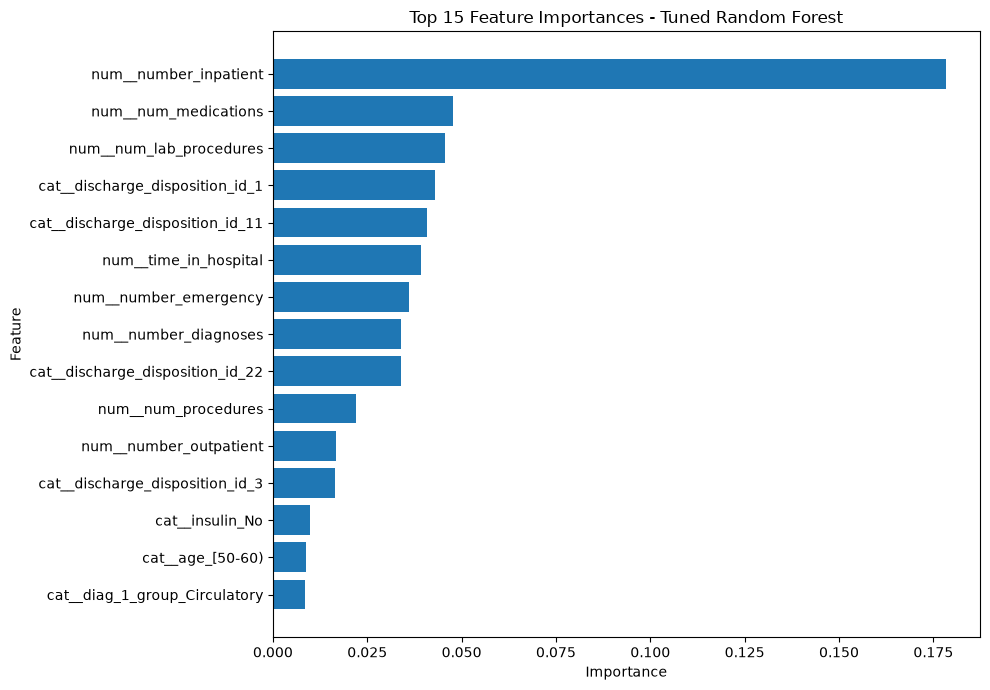

In [ ]:
# Visualize top 15 feature importances

top_features = (
    feature_importance
    .head(15)
    .sort_values("Importance")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 15 Feature Importances - Tuned Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [ ]:
# Save the final trained model and preprocessing pipeline

import joblib
import os

# Make sure the models folder exists
os.makedirs("../models", exist_ok=True)

# Save tuned Random Forest
joblib.dump(
    best_rf,
    "../models/random_forest.pkl"
)

# Save preprocessing pipeline
joblib.dump(
    preprocessor,
    "../models/preprocessor.pkl"
)

print("Final model and preprocessor saved successfully.")

print("\nModel file exists:",
      os.path.exists("../models/random_forest.pkl"))

print("Preprocessor file exists:",
      os.path.exists("../models/preprocessor.pkl"))

Final model and preprocessor saved successfully.

Model file exists: True
Preprocessor file exists: True


In [ ]:
# Verify that the saved model and preprocessor can be loaded

import joblib

loaded_model = joblib.load("../models/random_forest.pkl")
loaded_preprocessor = joblib.load("../models/preprocessor.pkl")

print("Saved model loaded successfully.")
print("Saved preprocessor loaded successfully.")

print("\nModel type:", type(loaded_model))
print("Preprocessor type:", type(loaded_preprocessor))

Saved model loaded successfully.
Saved preprocessor loaded successfully.

Model type: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
Preprocessor type: <class 'sklearn.compose._column_transformer.ColumnTransformer'>


In [ ]:
# Verify prediction using the saved model and preprocessor

# Transform the test data using the loaded preprocessor
X_test_loaded = loaded_preprocessor.transform(X_test)

# Generate predictions
y_pred_loaded = loaded_model.predict(X_test_loaded)

# Generate prediction probabilities
y_prob_loaded = loaded_model.predict_proba(X_test_loaded)[:, 1]

print("Prediction verification completed.")

print("\nNumber of predictions:", len(y_pred_loaded))
print("Number of actual values:", len(y_test))

print("\nFirst 10 predictions:")
print(y_pred_loaded[:10])

print("\nFirst 10 prediction probabilities:")
print(y_prob_loaded[:10])

Prediction verification completed.

Number of predictions: 20153
Number of actual values: 20153

First 10 predictions:
[1 0 0 0 0 0 0 1 0 0]

First 10 prediction probabilities:
[0.51896735 0.38070684 0.45755555 0.447861   0.40819588 0.37463527
 0.32943955 0.63209677 0.46821993 0.36250358]


In [ ]:
# Connect to SQLite database

import sqlite3

conn = sqlite3.connect("../data/hospital_readmission.db")

print("SQLite database connected successfully.")

SQLite database connected successfully.


In [ ]:
# Check available tables in the database

tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)

print("Available tables:")
tables

Available tables:


,name
0,hospital_data


In [ ]:
# Calculate overall 30-day readmission rate using SQL

query = """
SELECT
    COUNT(*) AS total_encounters,
    SUM(readmitted_30) AS readmitted_within_30_days,
    ROUND(100.0 * SUM(readmitted_30) / COUNT(*), 2) AS readmission_rate_percent
FROM hospital_data;
"""

sql_readmission_summary = pd.read_sql_query(
    query,
    conn
)

sql_readmission_summary

,total_encounters,readmitted_within_30_days,readmission_rate_percent
0,101766,11357,11.16


In [ ]:
# Calculate 30-day readmission rate by age group using SQL

query = """
SELECT
    age,
    COUNT(*) AS total_encounters,
    SUM(readmitted_30) AS readmitted_within_30_days,
    ROUND(
        100.0 * SUM(readmitted_30) / COUNT(*),
        2
    ) AS readmission_rate_percent
FROM hospital_data
GROUP BY age
ORDER BY readmission_rate_percent DESC;
"""

sql_age_readmission = pd.read_sql_query(
    query,
    conn
)

sql_age_readmission

,age,total_encounters,readmitted_within_30_days,readmission_rate_percent
0,[20-30),1657,236,14.24
1,[80-90),17197,2078,12.08
2,[70-80),26068,3069,11.77
3,[30-40),3775,424,11.23
4,[60-70),22483,2502,11.13
5,[90-100),2793,310,11.10
6,[40-50),9685,1027,10.60
7,[50-60),17256,1668,9.67
8,[10-20),691,40,5.79
9,[0-10),161,3,1.86


In [ ]:
# Calculate 30-day readmission rate by previous inpatient visits using SQL

query = """
SELECT
    number_inpatient,
    COUNT(*) AS total_encounters,
    SUM(readmitted_30) AS readmitted_within_30_days,
    ROUND(
        100.0 * SUM(readmitted_30) / COUNT(*),
        2
    ) AS readmission_rate_percent
FROM hospital_data
GROUP BY number_inpatient
ORDER BY number_inpatient;
"""

sql_inpatient_readmission = pd.read_sql_query(
    query,
    conn
)

sql_inpatient_readmission

,number_inpatient,total_encounters,readmitted_within_30_days,readmission_rate_percent
0,0,67630,5706,8.44
1,1,19521,2523,12.92
2,2,7566,1319,17.43
3,3,3411,692,20.29
4,4,1622,383,23.61
5,5,812,255,31.40
6,6,480,166,34.58
7,7,268,95,35.45
8,8,151,67,44.37
9,9,111,47,42.34


In [ ]:
# Calculate 30-day readmission rate by diabetes medication status using SQL

query = """
SELECT
    diabetesMed,
    COUNT(*) AS total_encounters,
    SUM(readmitted_30) AS readmitted_within_30_days,
    ROUND(
        100.0 * SUM(readmitted_30) / COUNT(*),
        2
    ) AS readmission_rate_percent
FROM hospital_data
GROUP BY diabetesMed
ORDER BY readmission_rate_percent DESC;
"""

sql_medication_readmission = pd.read_sql_query(
    query,
    conn
)

sql_medication_readmission

,diabetesMed,total_encounters,readmitted_within_30_days,readmission_rate_percent
0,Yes,78363,9111,11.63
1,No,23403,2246,9.60


In [ ]:
# Calculate 30-day readmission rate by hospital stay duration using SQL

query = """
SELECT
    time_in_hospital,
    COUNT(*) AS total_encounters,
    SUM(readmitted_30) AS readmitted_within_30_days,
    ROUND(
        100.0 * SUM(readmitted_30) / COUNT(*),
        2
    ) AS readmission_rate_percent
FROM hospital_data
GROUP BY time_in_hospital
ORDER BY time_in_hospital;
"""

sql_stay_readmission = pd.read_sql_query(
    query,
    conn
)

sql_stay_readmission

,time_in_hospital,total_encounters,readmitted_within_30_days,readmission_rate_percent
0,1,14208,1162,8.18
1,2,17224,1712,9.94
2,3,17756,1894,10.67
3,4,13924,1644,11.81
4,5,9966,1199,12.03
5,6,7539,949,12.59
6,7,5859,752,12.83
7,8,4391,625,14.23
8,9,3002,412,13.72
9,10,2342,336,14.35


In [ ]:
# Calculate 30-day readmission rate by primary diagnosis group using SQL

query = """
SELECT
    diag_1_group,
    COUNT(*) AS total_encounters,
    SUM(readmitted_30) AS readmitted_within_30_days,
    ROUND(
        100.0 * SUM(readmitted_30) / COUNT(*),
        2
    ) AS readmission_rate_percent
FROM hospital_data
GROUP BY diag_1_group
ORDER BY readmission_rate_percent DESC;
"""

sql_diagnosis_readmission = pd.read_sql_query(
    query,
    conn
)

sql_diagnosis_readmission

,diag_1_group,total_encounters,readmitted_within_30_days,readmission_rate_percent
0,Unknown,21,5,23.81
1,Supplementary,1644,266,16.18
2,Blood,1103,148,13.42
3,Diabetes,8757,1137,12.98
4,Metabolic,2602,319,12.26
5,Injury/Poisoning,6974,854,12.25
6,Mental,2262,276,12.20
7,Infectious,2768,317,11.45
8,Circulatory,30336,3474,11.45
9,Genitourinary,5078,549,10.81


In [ ]:
# Compare average healthcare utilization by readmission status using SQL

query = """
SELECT
    readmitted_30,
    COUNT(*) AS total_encounters,
    ROUND(AVG(number_outpatient), 2) AS avg_outpatient_visits,
    ROUND(AVG(number_emergency), 2) AS avg_emergency_visits,
    ROUND(AVG(number_inpatient), 2) AS avg_inpatient_visits
FROM hospital_data
GROUP BY readmitted_30
ORDER BY readmitted_30;
"""

sql_utilization_summary = pd.read_sql_query(
    query,
    conn
)

sql_utilization_summary

,readmitted_30,total_encounters,avg_outpatient_visits,avg_emergency_visits,avg_inpatient_visits
0,0,90409,0.36,0.18,0.56
1,1,11357,0.44,0.36,1.22


In [ ]:
# Close the SQLite database connection

conn.close()

print("SQLite database connection closed successfully.")

SQLite database connection closed successfully.


## SQL Analysis Summary

SQL analysis was performed using SQLite to explore patterns related to 30-day hospital readmission.

### Key Findings

- The overall 30-day readmission rate was **11.16%**.
- Readmission rates varied across different age groups.
- Patients with more previous inpatient visits generally showed higher 30-day readmission rates.
- Patients receiving diabetes medication had an **11.63%** readmission rate compared with **9.60%** for patients not receiving diabetes medication.
- Readmission rates varied with the length of hospital stay.
- Readmission rates differed across primary diagnosis groups.
- Patients who were readmitted within 30 days had higher average previous healthcare utilization, particularly previous inpatient visits.

These SQL-based findings helped identify important patterns and supported the feature selection and machine learning stages of the project.